Generated physical scenario
radius    = 3.6180236011324896
distance  = 14.399168046153854
diffusion = 56.07728630393029
Ts        = 3.208420465615359
N         = 344698
mem_len   = 4
P         = [0.08992435 0.02884315 0.01400867 0.00865191]
P_scaled  = [30996.7421387   9942.17541253  4828.7615337   2982.29485428]
variances = [28209.38038083  9655.41177614  4761.11699283  2956.49231815]
Threshold search interval: 0.0 to 48749.97393920574
sum(P_scaled) = 48749.97393920574


,threshold,real_BER,estimated_BER,abs_error,abs_log10_error
0,0.000000,0.5000,0.500000,5.960464e-08,4.412331e-08
1,97.695339,0.4375,0.398148,3.935227e-02,4.093381e-02
2,195.390677,0.4375,0.403650,3.384995e-02,3.497304e-02
3,293.086016,0.4375,0.405517,3.198320e-02,3.296920e-02
4,390.781354,0.4375,0.406070,3.142956e-02,3.237667e-02
5,488.476693,0.4375,0.406162,3.133810e-02,3.227885e-02
6,586.172031,0.4375,0.405863,3.163731e-02,3.259893e-02
7,683.867370,0.4375,0.405443,3.205657e-02,3.304778e-02
8,781.562708,0.4375,0.405232,3.226772e-02,3.327401e-02
9,879.258047,0.4375,0.405392,3.210801e-02,3.310289e-02



Summary
Mean abs raw error   : 0.016757759020675906
Mean abs log10 error : 0.1309295115240554
Max  abs log10 error : 1.0097665084033904

Best threshold from real BER      : 18659.809664104803
Minimum real BER                  : 1e-12
Best threshold from estimated BER : 18757.505002660324
Estimated BER at that threshold   : 2.0079437e-12


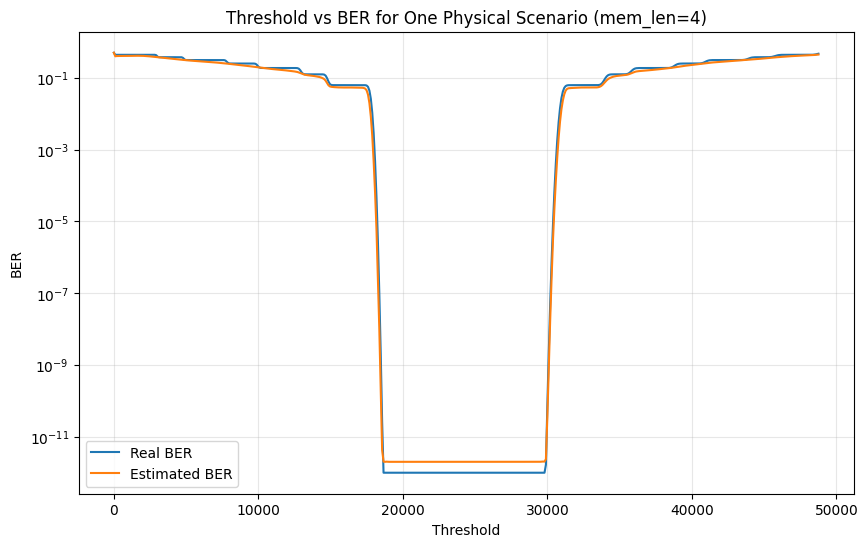

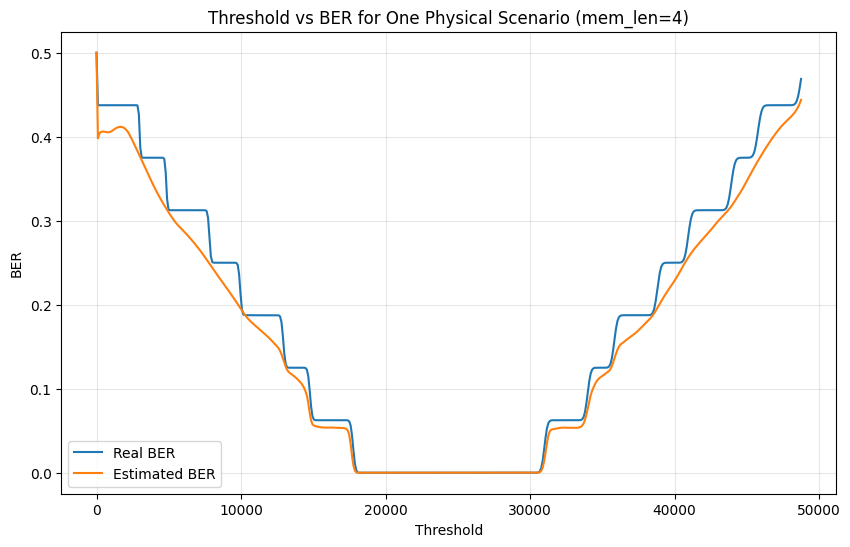

In [7]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_multiscale_rescnn_firstflag_posemb_selfattn_best_large_scaled_means_var_z01_5M.pth"
SCALER_PATH = "ber_boundedloghalf_multiscale_rescnn_firstflag_posemb_selfattn_scalers_large_scaled_means_var_z01_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 3
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 58

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(3, 4)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # [pos, abs, snr, first_flag, z0, z1]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(6, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, pos_emb_dim, seq_len) * 0.02)

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        self.self_attn = LightSelfAttention1D(
            dim=channels[2],
            num_heads=attn_heads,
            mlp_ratio=2.0,
            dropout=dropout
        ) if use_self_attention else nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(raw_out):
        log10_half = torch.log10(
            torch.tensor(0.5, device=raw_out.device, dtype=raw_out.dtype)
        )
        return log10_half - F.softplus(raw_out)

    @staticmethod
    def raw_to_ber(raw_out):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(raw_out)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:8, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)
    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    z0_ch = np.tile(z0_scaled, (1, L)).astype(np.float32)
    z1_ch = np.tile(z1_scaled, (1, L)).astype(np.float32)

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
            z0_ch,
            z1_ch,
        ],
        axis=1
    ).astype(np.float32)

    return seq, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

display(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Generated physical scenario
radius    = 3.6485676254025527
distance  = 10.135731959475024
diffusion = 51.36802218605558
Ts        = 0.4980983042603093
N         = 388928
mem_len   = 14
P         = [0.04142799 0.04231876 0.02565848 0.0172937  0.01260949 0.00970287
 0.00775952 0.00638653 0.00537483 0.00460425 0.00400148 0.00351953
 0.00312703 0.00280238]
P_scaled  = [16112.50422741 16458.95096582  9979.30028306  6726.00415258
  4904.18410377  3773.71821655  3017.89295298  2483.90207269
  2090.42027003  1790.72231556  1556.28863241  1368.84208825
  1216.19083916  1089.92548732]
variances = [15444.99560762 15762.42855834  9723.24663267  6609.68665458
  4842.3448386   3737.10231546  2994.475565    2468.03854651
  2079.18462511  1782.47737971  1550.06117049  1364.02441336
  1212.38776981  1086.8710979 ]
Threshold search interval: 0.0 to 72568.84660758519
sum(P_scaled) = 72568.84660758519
      threshold  real_BER  estimated_BER  abs_error  abs_log10_error
0      0.000000  0.500000       0.49

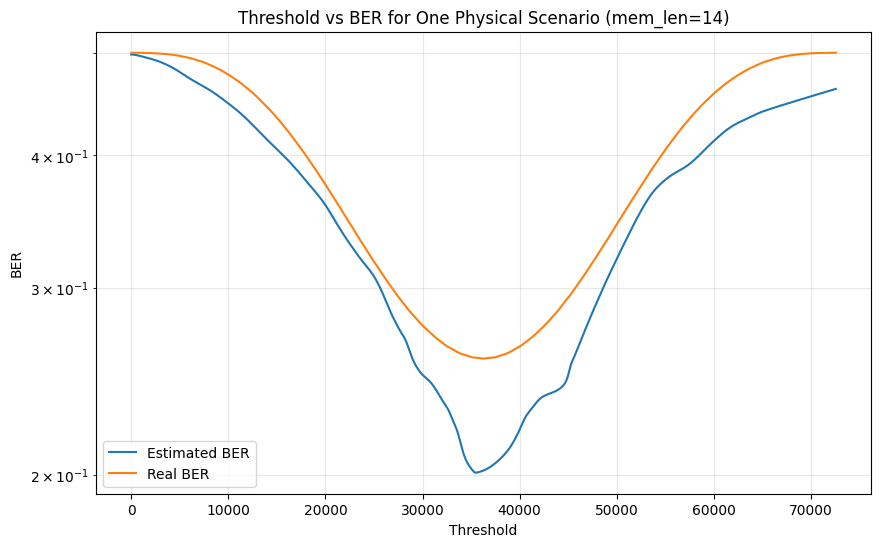

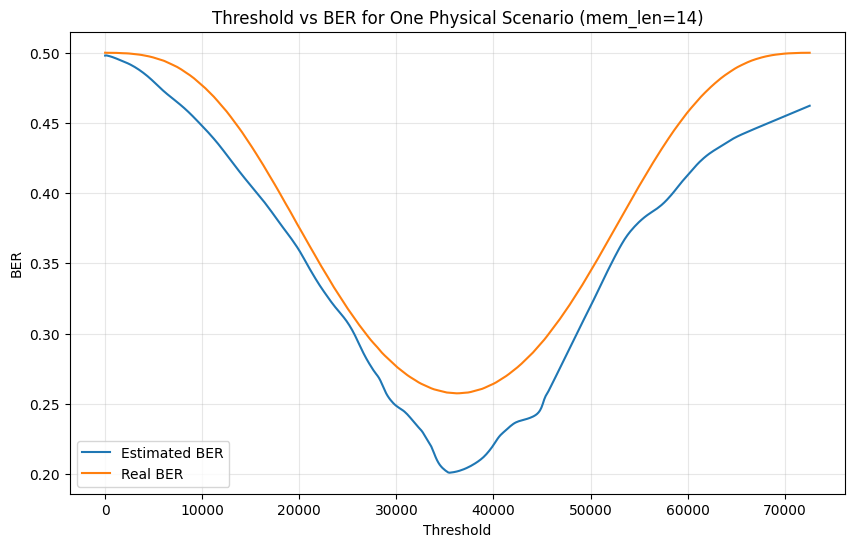

In [10]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalhmg_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalhmg_scalers_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 3
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.3, 0.5)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()